## Bank dataset classifier

In [157]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [158]:
# Load the dataset
df_train = pd.read_csv(os.path.join(os.path.abspath('..'), 'data', 'train.csv'))
df_test = pd.read_csv(os.path.join(os.path.abspath('..'), 'data', 'test.csv'))
df = pd.concat([df_train, df_test], ignore_index=True)


In [159]:
n_train = len(df_train)
n_test = len(df_test)

In [160]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0.0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0.0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0.0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0.0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1.0


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 18 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   id         1000000 non-null  int64  
 1   age        1000000 non-null  int64  
 2   job        1000000 non-null  object 
 3   marital    1000000 non-null  object 
 4   education  1000000 non-null  object 
 5   default    1000000 non-null  object 
 6   balance    1000000 non-null  int64  
 7   housing    1000000 non-null  object 
 8   loan       1000000 non-null  object 
 9   contact    1000000 non-null  object 
 10  day        1000000 non-null  int64  
 11  month      1000000 non-null  object 
 12  duration   1000000 non-null  int64  
 13  campaign   1000000 non-null  int64  
 14  pdays      1000000 non-null  int64  
 15  previous   1000000 non-null  int64  
 16  poutcome   1000000 non-null  object 
 17  y          750000 non-null   float64
dtypes: float64(1), int64(8), object(9)
memory u

In [162]:
df.describe()

,id,age,balance,day,duration,campaign,pdays,previous,y
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,750000.000000
mean,499999.500000,40.927879,1202.407136,16.116924,256.007423,2.576143,22.379557,0.299841,0.120651
std,288675.278932,10.094523,2812.750998,8.252748,272.268420,2.716302,77.219149,1.348254,0.325721
min,0.000000,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,249999.750000,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,499999.500000,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,749999.250000,48.000000,1390.000000,21.000000,359.000000,3.000000,-1.000000,0.000000,0.000000
max,999999.000000,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


In [163]:
print(df['poutcome'].value_counts())
print(df['pdays'].value_counts())

poutcome
unknown    896565
failure     59959
success     23694
other       19782
Name: count, dtype: int64
pdays
-1      896546
 182      3331
 92       3047
 183      2755
 91       2290
         ...  
 614         1
 794         1
 735         1
 759         1
 624         1
Name: count, Length: 614, dtype: int64


In [164]:
df.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

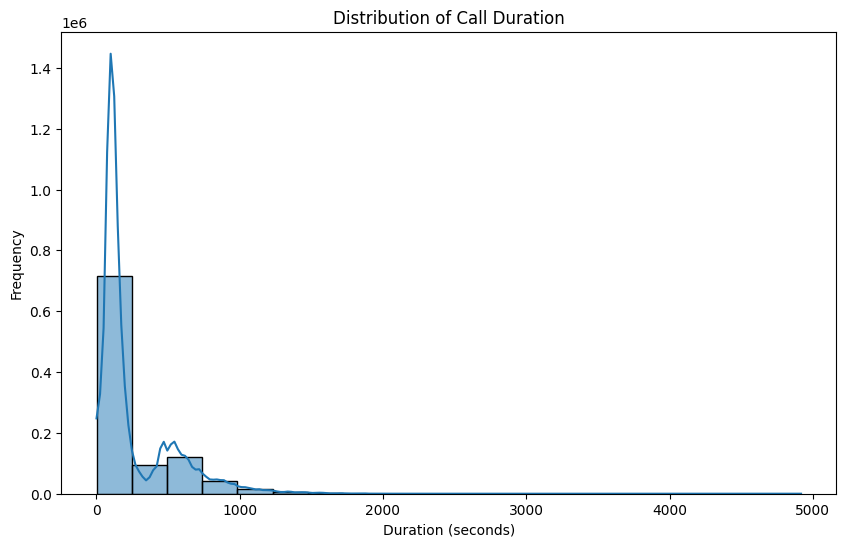

In [165]:
# Univariate analysis for call duration
plt.figure(figsize=(10, 6))
sns.histplot(df['duration'], bins=20, kde=True)
plt.title('Distribution of Call Duration')
plt.xlabel('Duration (seconds)')        
plt.ylabel('Frequency')
plt.show()

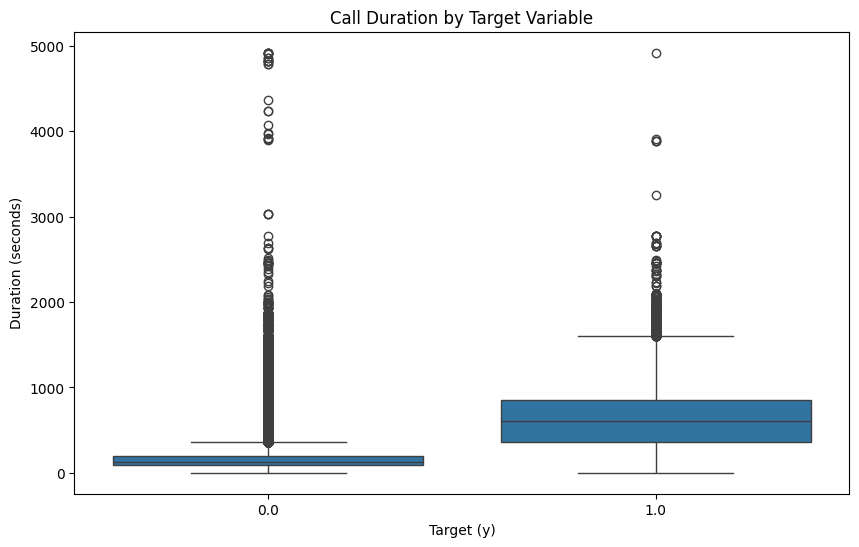

In [166]:
# Bivariate analysis for call duration vs target
plt.figure(figsize=(10, 6))
sns.boxplot(x='y', y='duration', data=df)
plt.title('Call Duration by Target Variable')
plt.xlabel('Target (y)')    
plt.ylabel('Duration (seconds)')
plt.show()

C:\Users\Ashish Savaliya\AppData\Local\Temp\ipykernel_19124\1578303397.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='job', y='balance', hue='y', data=df, ci=None)


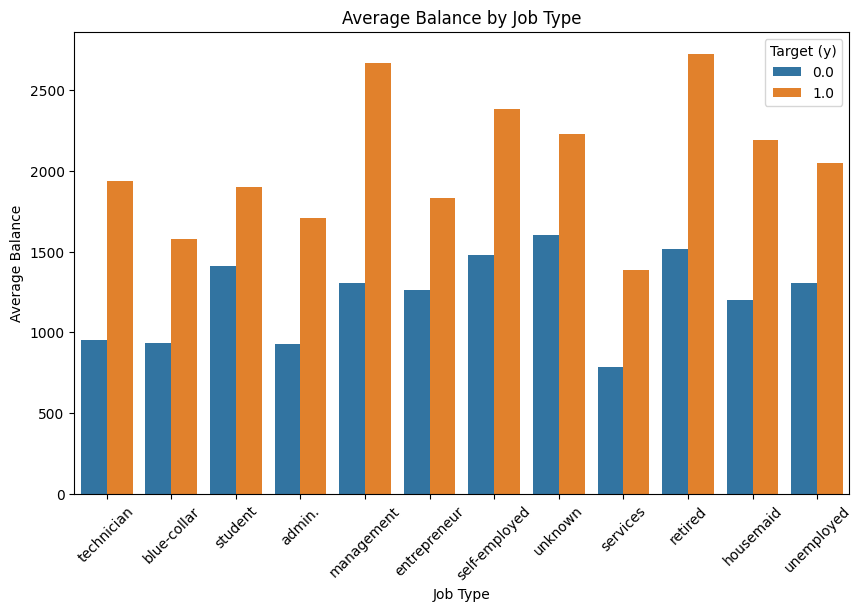

In [167]:
# Bivariate analysis for Job vs balance
plt.figure(figsize=(10, 6))
sns.barplot(x='job', y='balance', hue='y', data=df, ci=None)
plt.title('Average Balance by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Average Balance')
plt.xticks(rotation=45)
plt.legend(title='Target (y)')
plt.show()

C:\Users\Ashish Savaliya\AppData\Local\Temp\ipykernel_19124\242038595.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
C:\Users\Ashish Savaliya\AppData\Local\Temp\ipykernel_19124\242038595.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
C:\Users\Ashish Savaliya\AppData\Local\Temp\ipykernel_19124\242038595.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
C:\Users\Ashish Savaliya\AppData\Local\Temp\ipykernel_19124\242038595.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or usin

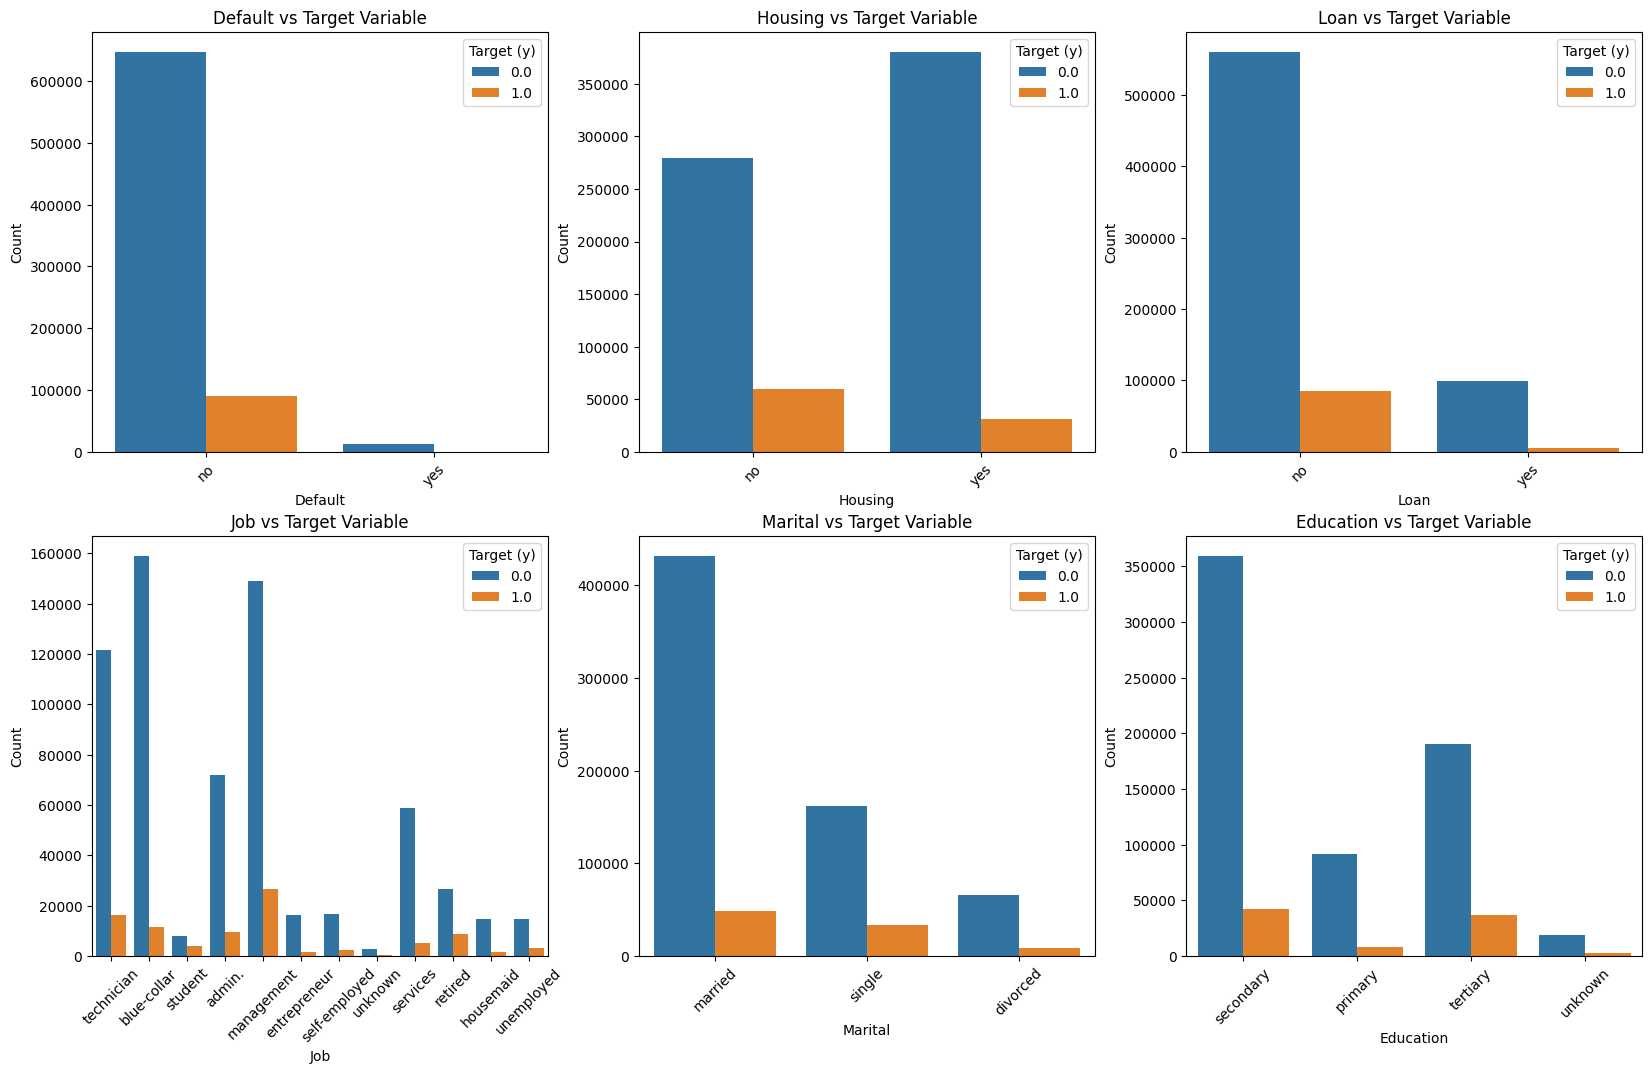

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [168]:
# Bivariate analysis
columns = ['default', 'housing', 'loan', 'job', 'marital', 'education']

# Create subplots for each categorical variable
fig, axes = plt.subplots(nrows=2, ncols=int(len(columns)/2), figsize=(20, 12))
axes = axes.flatten()

for i, column in enumerate(columns):
    plt.figure(figsize=(10, 6))
    sns.countplot(x=column, hue='y', data=df, ax=axes[i])
    axes[i].set_title(f'{column.capitalize()} vs Target Variable')
    axes[i].set_xlabel(column.capitalize())
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Target (y)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [169]:
print(df['default'].value_counts())
print(df['housing'].value_counts())
print(df['loan'].value_counts())

default
no     982994
yes     17006
Name: count, dtype: int64
housing
yes    547822
no     452178
Name: count, dtype: int64
loan
no     859980
yes    140020
Name: count, dtype: int64


In [170]:
# Transform categorical variables with one-hot encoding
df = pd.get_dummies(df, columns=['job', 'marital', 'education', 'contact', 'poutcome'], drop_first=True, dtype=int)

In [171]:
# Transform month into cyclical features
df['month_sin'] = np.sin(2 * np.pi * df['month'].astype('category').cat.codes / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'].astype('category').cat.codes / 12)

In [172]:
# Binomial encoding for binary variables
df['default'] = df['default'].map({'yes': 1, 'no': 0})
df['housing'] = df['housing'].map({'yes': 1, 'no': 0})
df['loan'] = df['loan'].map({'yes': 1, 'no': 0})

In [173]:
# Drop unnecessary columns
df = df.drop(['id', 'day', 'month'], axis=1)

In [174]:
df.head()

,age,default,balance,housing,loan,duration,campaign,pdays,previous,y,...,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown,month_sin,month_cos
0,42,0,7,0,0,117,3,-1,0,0.0,...,1,0,0,0,0,0,0,1,5.000000e-01,8.660254e-01
1,38,0,514,0,0,185,1,-1,0,0.0,...,1,0,0,0,1,0,0,1,1.224647e-16,-1.000000e+00
2,36,0,602,1,0,111,2,-1,0,0.0,...,1,0,0,0,1,0,0,1,-8.660254e-01,-5.000000e-01
3,27,0,34,1,0,10,2,-1,0,0.0,...,1,0,0,0,1,0,0,1,-8.660254e-01,-5.000000e-01
4,26,0,889,1,0,902,1,-1,0,1.0,...,1,0,0,0,0,0,0,1,1.000000e+00,6.123234e-17


In [175]:
df.dtypes

age                      int64
default                  int64
balance                  int64
housing                  int64
loan                     int64
duration                 int64
campaign                 int64
pdays                    int64
previous                 int64
y                      float64
job_blue-collar          int32
job_entrepreneur         int32
job_housemaid            int32
job_management           int32
job_retired              int32
job_self-employed        int32
job_services             int32
job_student              int32
job_technician           int32
job_unemployed           int32
job_unknown              int32
marital_married          int32
marital_single           int32
education_secondary      int32
education_tertiary       int32
education_unknown        int32
contact_telephone        int32
contact_unknown          int32
poutcome_other           int32
poutcome_success         int32
poutcome_unknown         int32
month_sin              float64
month_co

In [176]:
df_train_clean = df.iloc[:n_train].reset_index(drop=True)
df_test_clean = df.iloc[n_train:].reset_index(drop=True)

In [177]:
# Save the cleaned datasets
df_train_clean.to_csv(os.path.join(os.path.abspath('..'), 'data', 'train_clean.csv'), index=False)
df_test_clean.to_csv(os.path.join(os.path.abspath('..'), 'data', 'test_clean.csv'), index=False)